# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, TimeDistributed, Reshape
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [2]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# First removing the path by split and then splitting the string to get the label
# input_path = [i for i in glob('Dataset\*\*\*.mp4')]
input_path = [i for i in glob('MP_Data\*\*.npy')]
output_label = [i.split("\\")[-1] for i in glob('MP_data\*')] 

print(output_label)
# input_path

['Bank', 'big large', 'Bird', 'Black', 'Boy', 'Brother', 'Car', 'Cell phone', 'Court', 'Cow', 'Death', 'Dog', 'dry', 'Election', 'Fall', 'Fan', 'Father', 'Girl', 'good', 'Good Morning', 'happy', 'Hat', 'Hello', 'hot', 'House', 'I', 'it', 'long', 'loud', 'Monday', 'new', 'Paint', 'Pen', 'Priest', 'quiet', 'Red', 'Shoes', 'short', 'small little', 'Store or Shop', 'Summer', 'T-Shirt', 'Teacher', 'Thank you', 'Time', 'train ticket', 'White', 'Window', 'Year', 'you (plural)']


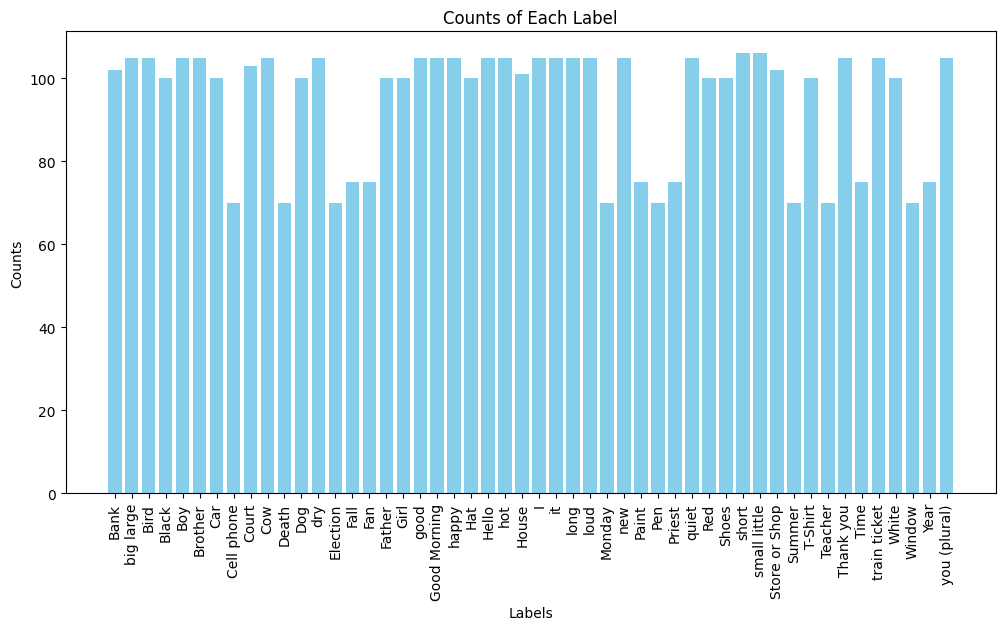

In [4]:
import matplotlib.pyplot as plt

# Count the occurrences of each label in y
label_counts = [len(os.listdir(i)) for i in glob('MP_data\*')]

# Create a bar graph
plt.figure(figsize=(12, 6))
plt.bar(output_label, label_counts, color='skyblue')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Counts of Each Label')
plt.xticks(rotation=90)
plt.show()

In [5]:
labels = pd.Series(output_label).unique()
labels = pd.Series(labels).to_list()

train_path = pd.Series(input_path)

train_path.sample(5),len(labels)

(4574           MP_Data\Year\MVI_5047_upsampled.npy
 1310                 MP_Data\Election\MVI_8710.npy
 3042           MP_Data\Paint\MVI_4927_centered.npy
 3811    MP_Data\Store or Shop\MVI_3475_flipped.npy
 978               MP_Data\Cow\MVI_4158_flipped.npy
 dtype: object,
 50)

In [6]:
label_map = dict()

for i in range(len(labels)):
    for j in input_path:
        sep = j.split("\\")
        cur_label  = sep[-2].split(" ")[-1]
    label_map[i] = labels[i]
            
label_map    

{0: 'Bank',
 1: 'big large',
 2: 'Bird',
 3: 'Black',
 4: 'Boy',
 5: 'Brother',
 6: 'Car',
 7: 'Cell phone',
 8: 'Court',
 9: 'Cow',
 10: 'Death',
 11: 'Dog',
 12: 'dry',
 13: 'Election',
 14: 'Fall',
 15: 'Fan',
 16: 'Father',
 17: 'Girl',
 18: 'good',
 19: 'Good Morning',
 20: 'happy',
 21: 'Hat',
 22: 'Hello',
 23: 'hot',
 24: 'House',
 25: 'I',
 26: 'it',
 27: 'long',
 28: 'loud',
 29: 'Monday',
 30: 'new',
 31: 'Paint',
 32: 'Pen',
 33: 'Priest',
 34: 'quiet',
 35: 'Red',
 36: 'Shoes',
 37: 'short',
 38: 'small little',
 39: 'Store or Shop',
 40: 'Summer',
 41: 'T-Shirt',
 42: 'Teacher',
 43: 'Thank you',
 44: 'Time',
 45: 'train ticket',
 46: 'White',
 47: 'Window',
 48: 'Year',
 49: 'you (plural)'}

In [17]:
# Loading all the labeled videos in the dataset
X = []
y = []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label) 
    
    for video in label_videos:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        
        X.append(res)
        y.append(labels.index(label))      

len(X),len(y)

  0%|          | 0/50 [00:00<?, ?it/s]

(4730, 4730)

In [16]:
for i in range(len(X)):
    if len(X[i][0]) == 1662:
        print(i,y[i])

2738 28


In [18]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
print(f"Max frames: {max_frames}")

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)


Max frames: 154
(4730, 154, 258)


In [19]:
X= np.array(X)
y= np.array(y)
# X= tf.convert_to_tensor(X)
# y= tf.convert_to_tensor(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (3784, 154, 258)
X_val shape: (946, 154, 258)
y_train shape: (3784, 50)
y_val shape: (946, 50)


# Model

## Architecture

In [20]:
import keras

# input_shape = (79, 1662)
input_shape = X_train[0].shape #(79, 1662)
num_classes =  len(label_map.keys())#50
input_shape,num_classes

((154, 258), 50)

In [10]:


INCLUDE8_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,476,168 (9.45 MB)

 Trainable params: 2,476,168 (9.45 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:

INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirectio  (None, 154, 128)         165376    
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 154, 256)         263168    
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 154, 128)         164352    
 nal)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 19712)             0         
                                                                 
 dense_2 (Dense)             (None, 128)               2523264   
                                                      

In [12]:

INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 79, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 79, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,240 (9.95 MB)

 Trainable params: 2,607,240 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=25)
        #   ,callbacks=[early_stop])

Epoch 1/25
119/119 [==============================] - 18s 100ms/step - loss: 3.4856 - accuracy: 0.0862 - val_loss: 2.9607 - val_accuracy: 0.1427
Epoch 2/25
119/119 [==============================] - 11s 90ms/step - loss: 2.7395 - accuracy: 0.1908 - val_loss: 2.4170 - val_accuracy: 0.2759
Epoch 3/25
119/119 [==============================] - 11s 91ms/step - loss: 2.1361 - accuracy: 0.3565 - val_loss: 2.0325 - val_accuracy: 0.3827
Epoch 4/25
119/119 [==============================] - 10s 85ms/step - loss: 1.5507 - accuracy: 0.5222 - val_loss: 1.5298 - val_accuracy: 0.5518
Epoch 5/25
119/119 [==============================] - 10s 87ms/step - loss: 1.1496 - accuracy: 0.6483 - val_loss: 1.4568 - val_accuracy: 0.5772
Epoch 6/25
119/119 [==============================] - 10s 87ms/step - loss: 0.9069 - accuracy: 0.7223 - val_loss: 1.1610 - val_accuracy: 0.6744
Epoch 7/25
119/119 [==============================] - 10s 86ms/step - loss: 0.6775 - accuracy: 0.7936 - val_loss: 0.9860 - val_accuracy

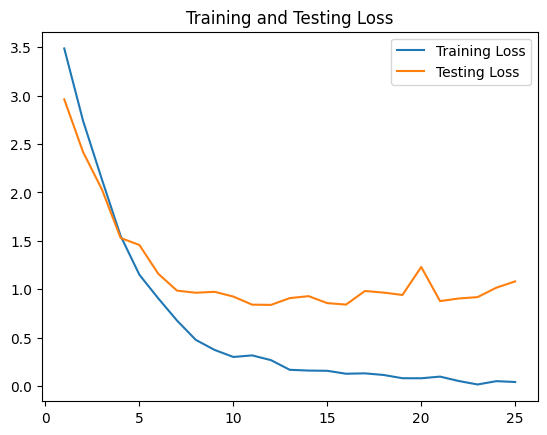

<Figure size 640x480 with 0 Axes>

In [28]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

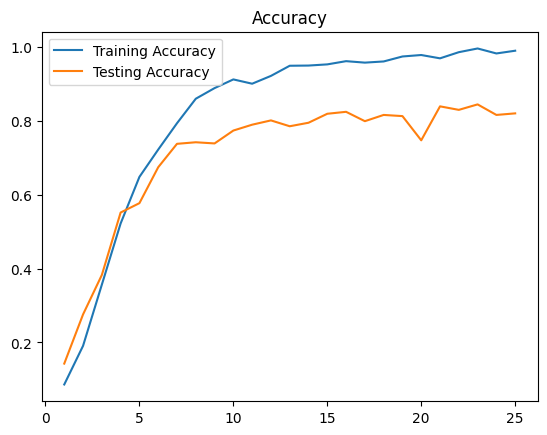

<Figure size 640x480 with 0 Axes>

In [29]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

In [30]:
# Predict probabilities for the test data
probabilities = model.predict(X_val)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)

total = len(X_val)
pred = 0
for i in range(total):
   if (label_map[predicted_classes[i]]) == (label_map[np.argmax(y_val[i])]):
         pred += 1

acc = (pred/total)*100

acc, total,pred

30/30 [==============================] - 2s 40ms/step


(82.02959830866807, 946, 776)

In [31]:
# model.save('INCLUDE_8_V1.h5')
try:
    os.mkdir("Model")
except:
    pass

model.save("Model\INCLUDE_50_V3_noFace.h5")